In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CIFAR10
from pytorchcv.model_provider import get_model
from torchinfo import summary
import matplotlib.pyplot as plt
from tqdm import *

In [2]:
#预训练的网络参数使用了标准化的数据集，因此在预处理中引入标准化
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]
transform = transforms.Compose([
    transforms.ToTensor(),  # 自动缩放到 [0,1]
    transforms.Normalize(mean, std)  #执行标准化
])
#加载数据集，由于是预先下载好的，所以download使用False
testset = CIFAR10(root='datas', train=False, download=False, transform=transform)

In [3]:
#加载网络，网络权重也都下载好了
net = get_model("resnet56_cifar10", pretrained=False)
state_dict = torch.load("./models/resnet56_cifar10-0452-628c42a2.pth")
net.load_state_dict(state_dict)
net.eval()
summary(net)

Layer (type:depth-idx)                             Param #
CIFARResNet                                        --
├─Sequential: 1-1                                  --
│    └─ConvBlock: 2-1                              --
│    │    └─Conv2d: 3-1                            432
│    │    └─BatchNorm2d: 3-2                       32
│    │    └─ReLU: 3-3                              --
│    └─Sequential: 2-2                             --
│    │    └─ResUnit: 3-4                           4,672
│    │    └─ResUnit: 3-5                           4,672
│    │    └─ResUnit: 3-6                           4,672
│    │    └─ResUnit: 3-7                           4,672
│    │    └─ResUnit: 3-8                           4,672
│    │    └─ResUnit: 3-9                           4,672
│    │    └─ResUnit: 3-10                          4,672
│    │    └─ResUnit: 3-11                          4,672
│    │    └─ResUnit: 3-12                          4,672
│    └─Sequential: 2-3                           

In [4]:
def image_display(label1, image1, label2, image2, dr):
    image1_denorm = image1 * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    image1_denorm.data.clamp_(0, 1)
    image2_denorm = image2 * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    image2_denorm.data.clamp_(0, 1)

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.title(f"Label: {label1}")
    # plt.imshow(image_denorm.squeeze().permute(1, 2, 0), interpolation='hanning')
    plt.imshow(image1_denorm.squeeze().permute(1, 2, 0))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Label: {label2}, dr: {dr:.2f}")
    # plt.imshow(adv_image_denorm.squeeze().permute(1, 2, 0), interpolation='hanning')
    plt.imshow(image2_denorm.squeeze().permute(1, 2, 0))
    plt.axis("off")

    plt.show()

def optimize_display(output_history, classes):
    plt.figure(figsize=(12, 6))
    for i in range(len(classes)):
        plt.plot(output_history[:, i], label=f'{classes[i]}')

    plt.xlabel('Epoch')
    plt.ylabel('Probability')
    plt.title('Output Probability Trends Over Epochs')
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [5]:
def Damage(data, target):
    # 初始化扰动变量（需梯度跟踪）
    lr = 0.01  # 学习率
    dr = 0.9  # 抛弃率
    max_iter = 200  # 最大迭代次数
    output_history = torch.zeros(max_iter, 10)
    delta = torch.rand_like(data, requires_grad=True)
    optimizer = torch.optim.SGD([delta], lr=lr)

    data_denorm = data * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)

    for epoch in tqdm(range(max_iter)):
        optimizer.zero_grad()

        # 1. 展平掩膜
        figure = torch.sum(delta.data, dim=1, keepdim=True)
        flattened = figure.flatten()
        # 2. 计算 dr 的分界点
        k = int(dr * len(flattened))
        kth_value = torch.kthvalue(flattened, k).values
        # 3. 生成掩码
        mask = (figure >= kth_value).float()
        delta.data = mask.expand(-1, 3, -1, -1).clone()
        # 4. 生成样本
        perturbed_data = data_denorm * delta
        adv_image = (perturbed_data - torch.tensor(mean).view(1, 3, 1, 1)) / torch.tensor(std).view(1, 3, 1, 1)
        # 5. 模型预测
        logits = net(adv_image)
        output_history[epoch] = logits.data
        # 6. 计算松弛函数
        logits_target = logits[:, target]
        logits_abs = logits.abs()
        logits_other = torch.sum(logits_abs[:, [i for i in range(logits_abs.shape[1]) if i != target]], dim=1)[0]
        loss = logits_other - logits_target
        # 7. 早停
        if dr < 0.6:
            if logits_target > (torch.max(logits[:, [i for i in range(logits.shape[1]) if i != target]], dim=1)[0] + 1):
                break
        # 8. 反向传播和优化
        loss.backward(retain_graph=True)
        optimizer.step()
        dr = dr * (1 - lr)

    # 最终样本
    print(dr)
    image = adv_image.detach().clone()  #抛弃梯度信息
    label = logits.max(1, keepdim=True)[1]  # get the index of the max log-probability
    return image, label, output_history, dr, epoch

 40%|███████████████████████████████████████████████████████▋                                                                                     | 79/200 [00:02<00:03, 33.76it/s]


0.40683928523982793


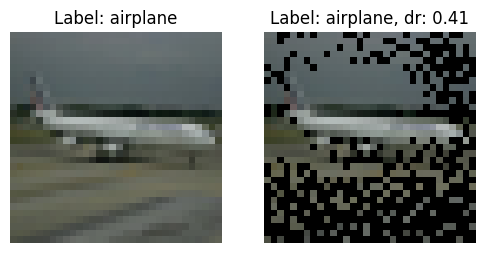

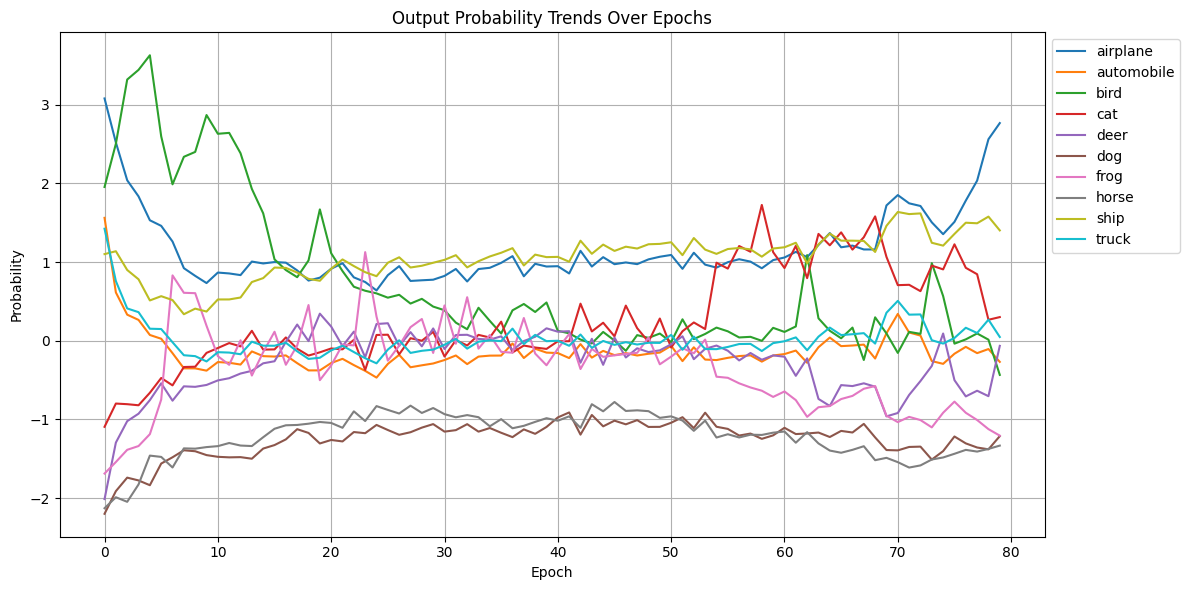

 34%|███████████████████████████████████████████████▉                                                                                             | 68/200 [00:01<00:03, 34.23it/s]


0.45439729990836275


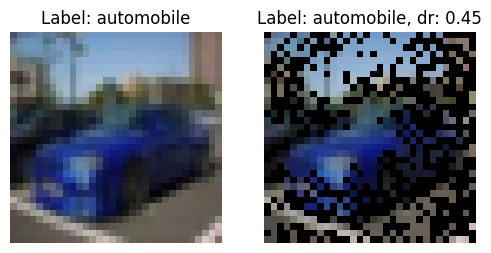

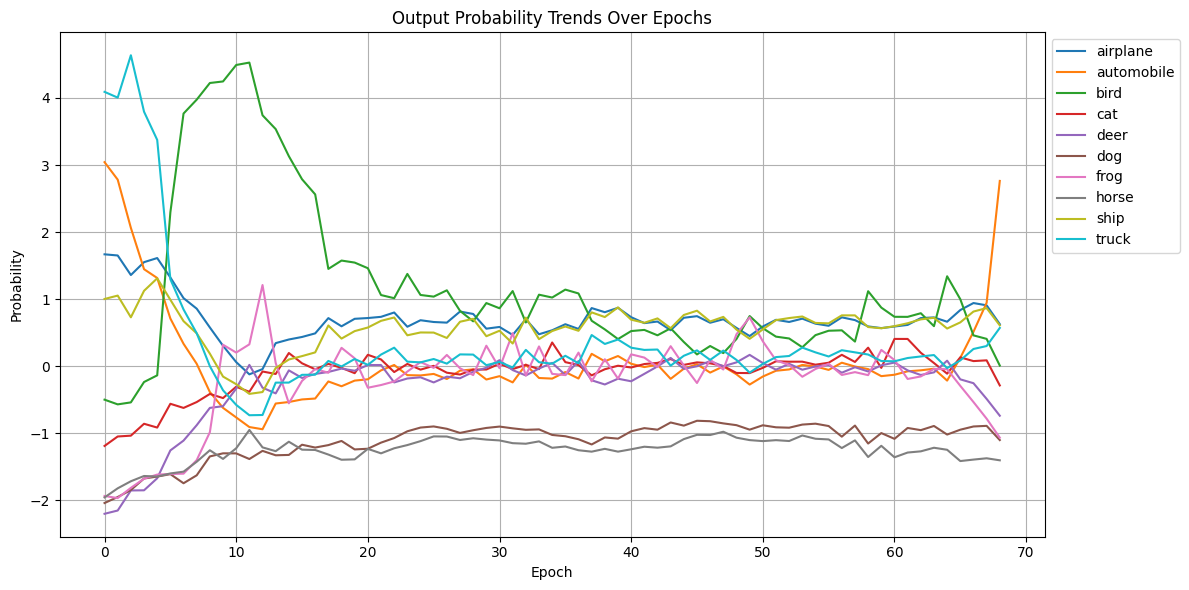

 20%|████████████████████████████▉                                                                                                                | 41/200 [00:01<00:04, 33.01it/s]


0.5960538368855853


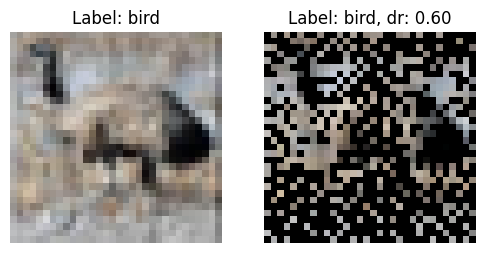

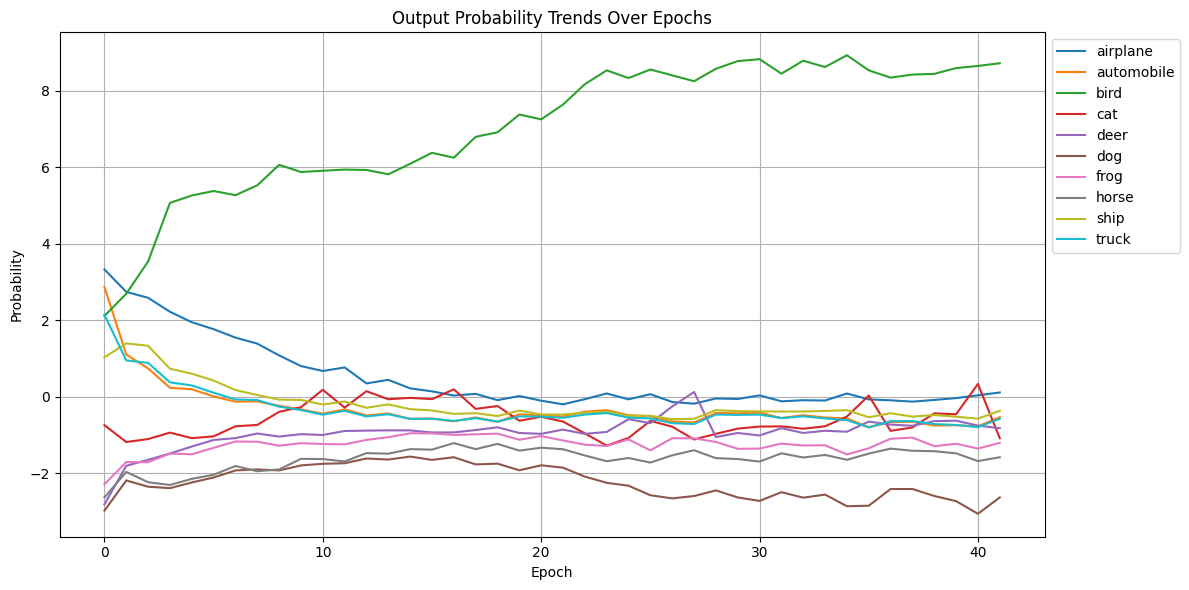

 20%|████████████████████████████▉                                                                                                                | 41/200 [00:01<00:04, 32.87it/s]


0.5960538368855853


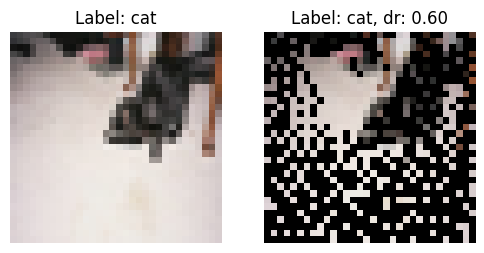

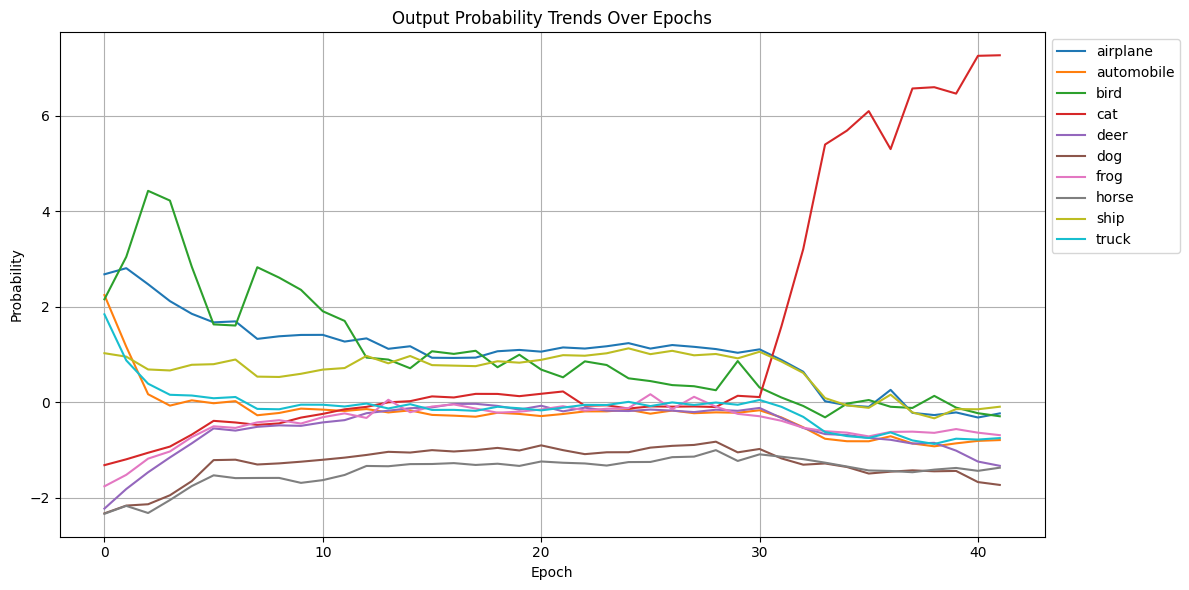

 20%|████████████████████████████▉                                                                                                                | 41/200 [00:01<00:05, 31.20it/s]

0.5960538368855853


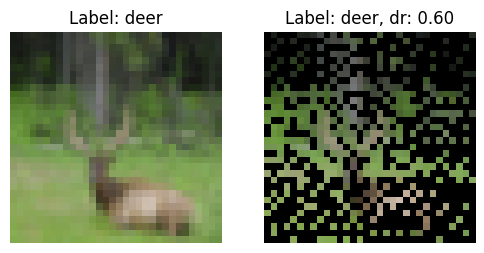

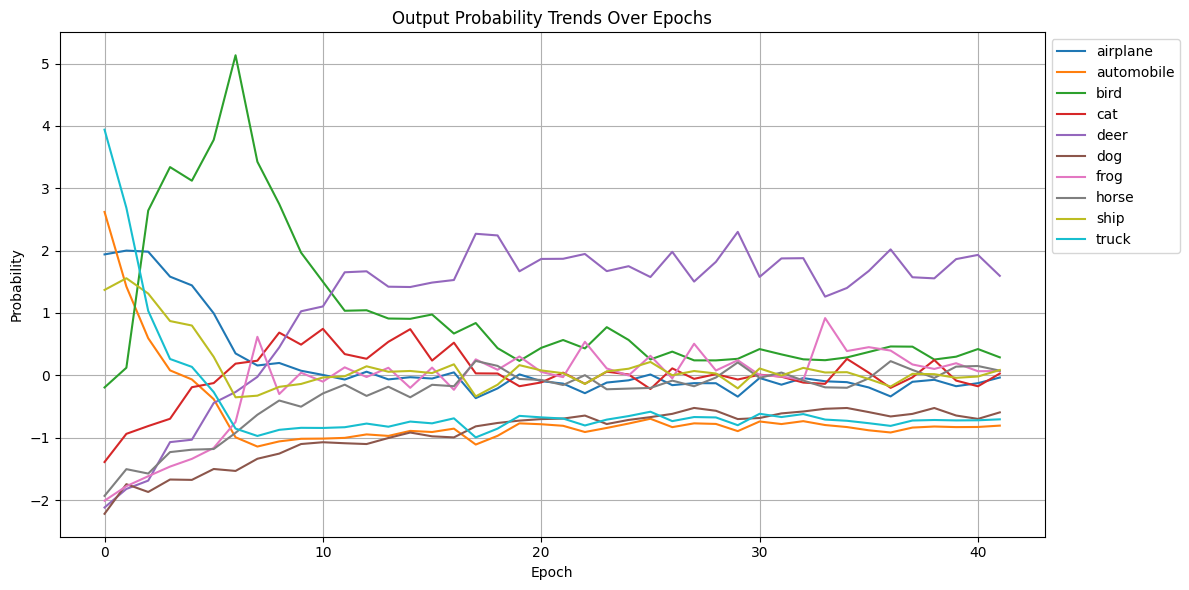

 29%|████████████████████████████████████████▉                                                                                                    | 58/200 [00:01<00:04, 32.56it/s]

0.5024395246930774


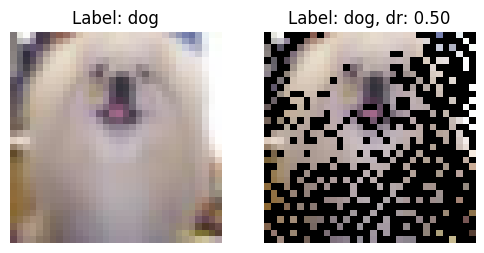

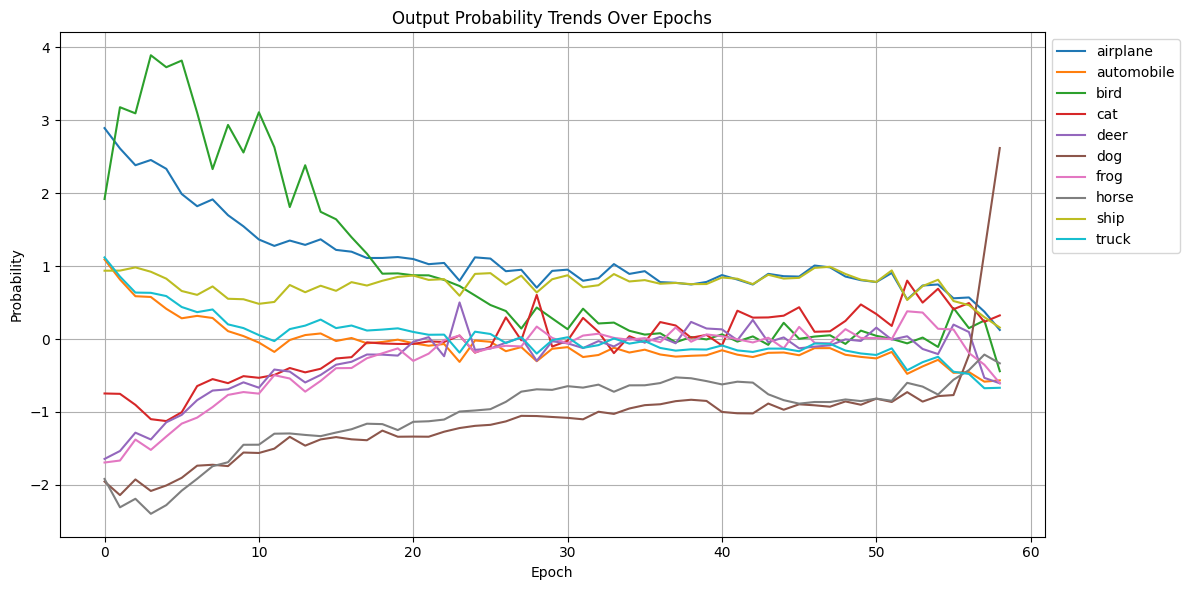

 20%|████████████████████████████▉                                                                                                                | 41/200 [00:01<00:04, 32.44it/s]


0.5960538368855853


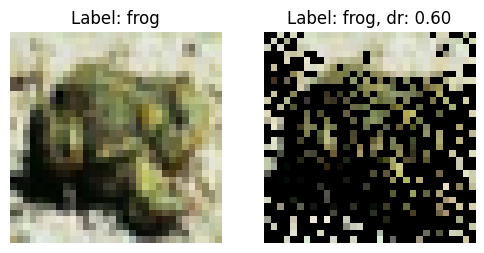

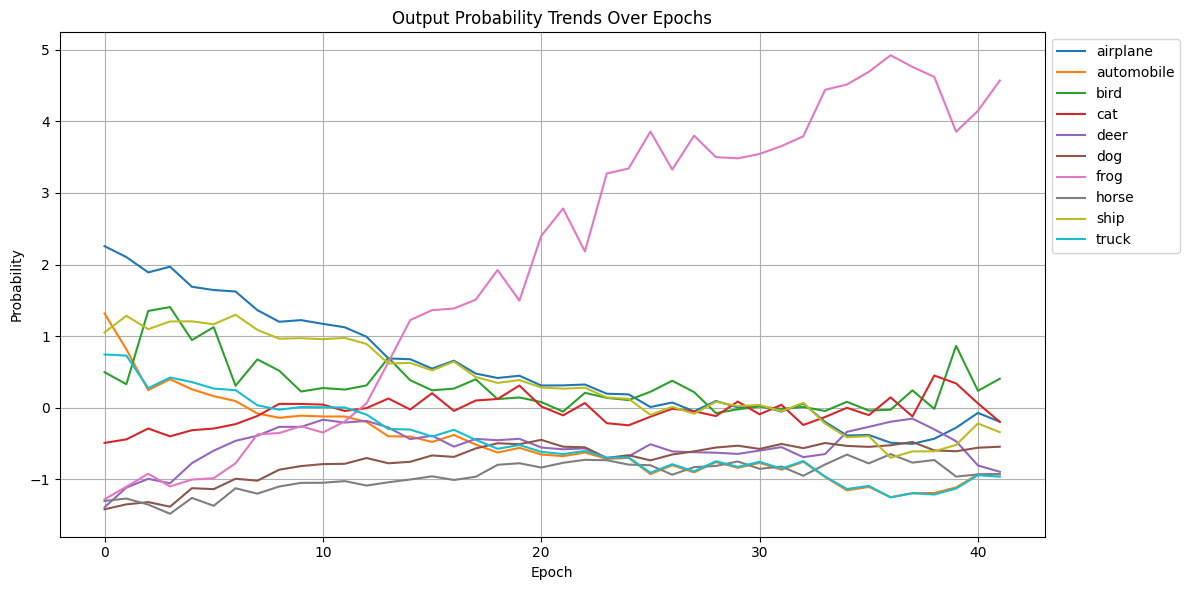

 42%|███████████████████████████████████████████████████████████▉                                                                                 | 85/200 [00:02<00:03, 33.09it/s]


0.3830311110497892


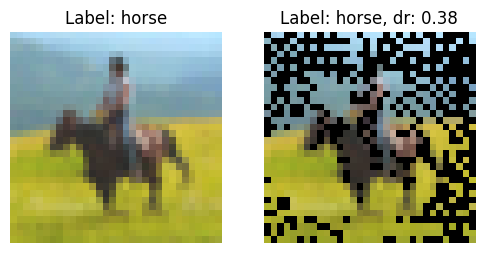

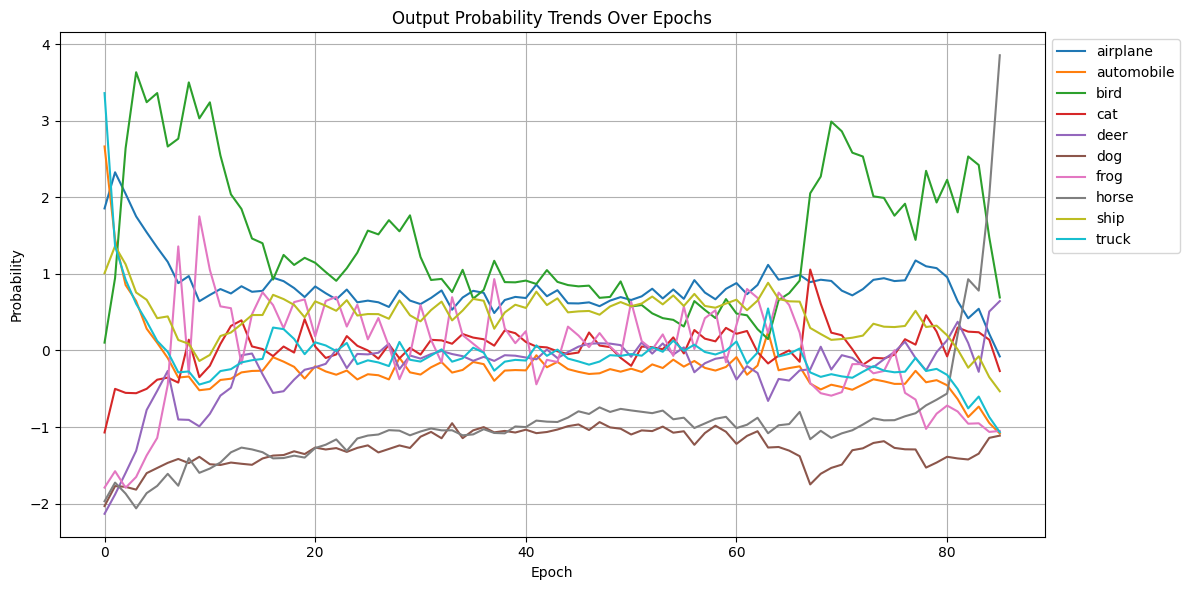

 28%|███████████████████████████████████████▍                                                                                                     | 56/200 [00:01<00:04, 30.23it/s]

0.5126410822294434


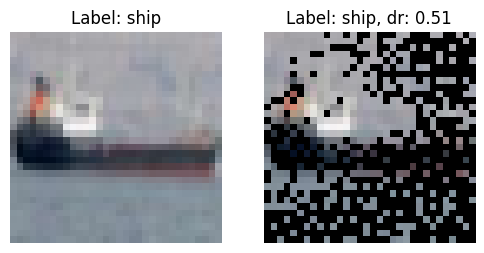

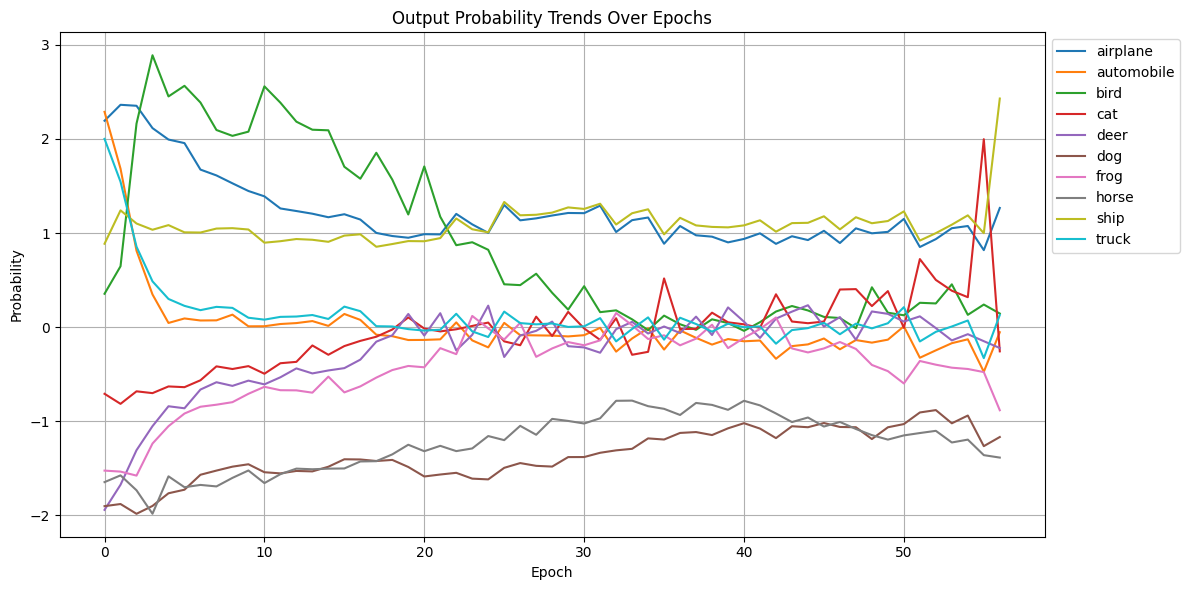

 50%|█████████████████████████████████████████████████████████████████████▊                                                                       | 99/200 [00:03<00:03, 28.65it/s]


0.33275667388475383


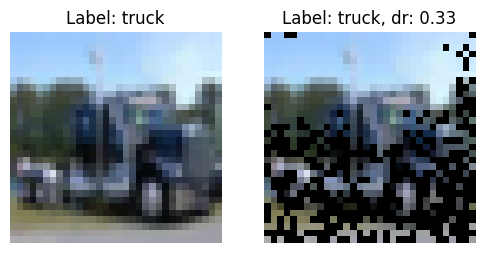

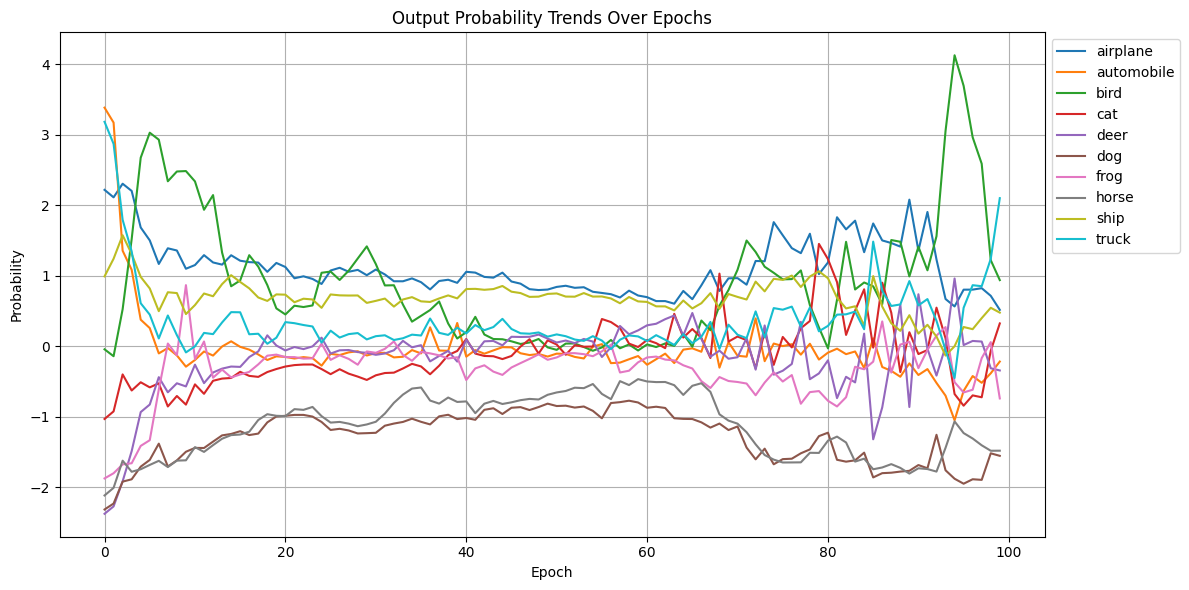

In [6]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
#依次攻击，所以batch_size为1
test_loader = DataLoader(testset, 1, shuffle=True)
j = 0
for data, target in test_loader:
    #在攻击之前先检查一下是否正确识别
    output = net(data)
    init_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability
    # If the initial prediction is wrong, don't bother attacking, just move on
    if init_pred.item() != target.item():
        continue
    if init_pred != j:
        continue

    image, label, output_history, dr, epoch = Damage(data, target)
    image_display(classes[target], data, classes[label], image, dr)
    optimize_display(output_history[:epoch+1, :], classes)
    
    j = j + 1
    if j == 10:
        break